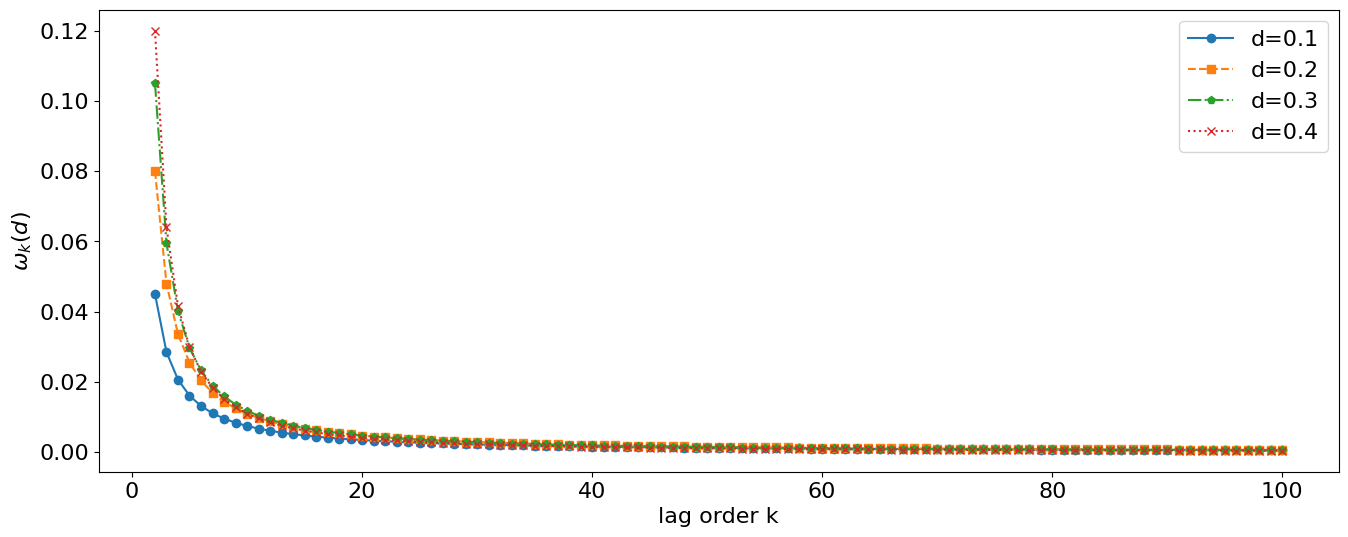

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

def cal_weight(d, lag_k):
    weights = np.arange(0, lag_k).reshape(-1, 1)
    weights = (weights - d) / (weights + 1)
    weights = np.cumprod(weights)

    return -weights

def cal_weight_by_gamma(d, lag_k):
    weights = np.zeros(lag_k)
    for i in range(lag_k):
        weights[i] = gamma(i + 1 - d) / gamma(-d) / gamma(i + 2)
    return -weights

plt.figure(figsize=(16, 6))
marker_list = ['o', 's', 'p', 'x']
line_list = ['-', '--', '-.', ':']
start = 1
for i, d in enumerate([0.1, 0.2, 0.3, 0.4]):
    lag_k = 100
    k = np.arange(1, lag_k+1)
    weights = cal_weight(d, lag_k)
    plt.plot(k[start:], weights[start:], marker=marker_list[i], linestyle=line_list[i], label=f'd={d}')

plt.xlabel('lag order k', fontsize=16)
plt.ylabel('$\omega_k(d)$', fontsize=16)

plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=16)
plt.show()